# Meta-Analysis — Algorithm Selection Pipeline

This notebook builds a predictive meta-learning pipeline on top of the instance space introduced in `entrega_final.ipynb §9`. The goal is to go beyond the descriptive footprint (which algorithm wins *where* on observed datasets) and train a meta-classifier that can **recommend the best algorithm for an unseen dataset** given its structural and KNN-specific meta-features.

The pipeline is self-contained: it loads the benchmark results, engineers 9 meta-features (6 structural + 3 KNN-specific), runs Leave-One-Dataset-Out cross-validation (LODO-CV) on all 40 datasets, and saves results to `results/tables/` for display in the main notebook.

In [1]:
import warnings, sys, os, copy
warnings.filterwarnings("ignore")

for _candidate in [".", "..", os.path.join(os.path.dirname(os.getcwd()), "")]:
    _candidate = os.path.abspath(_candidate)
    if os.path.isdir(os.path.join(_candidate, "src")):
        if _candidate not in sys.path:
            sys.path.insert(0, _candidate)
        os.chdir(_candidate)
        break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import skew as _sp_skew, spearmanr
from sklearn.decomposition import PCA
from sklearn.neighbors import NearestNeighbors, KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

from src.data.loader import load_all_datasets
from src.data.preprocessing import binarise_labels
from src.algorithms.fair_rank.multiclass import KNNFairRankMulticlass, KNNFairRankMulticlassJackknife, KNNFairRankMulticlassLOO

SEED = 42

META_LEARNERS = {
    "KNN-5":             Pipeline([("sc", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "LogisticReg":       Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(random_state=SEED, max_iter=500))]),
    "RandomForest":      RandomForestClassifier(n_estimators=100, random_state=SEED),
    "GradientBoosting":  GradientBoostingClassifier(n_estimators=100, random_state=SEED),
    "SVM":               Pipeline([("sc", StandardScaler()), ("clf", SVC(kernel="rbf", random_state=SEED))]),
    "FairRankMC":        KNNFairRankMulticlass(),
    "FairRankMC-JKK":   KNNFairRankMulticlassJackknife(),
    "FairRankMC-LOO":   KNNFairRankMulticlassLOO(),
}

print("Imports OK")

Imports OK


## 1 · Load data and benchmark results

In [2]:
datasets = load_all_datasets()
print(f"Loaded {len(datasets)} datasets")

_bench_5 = "results/tables/benchmark_5rep.csv"
_bench_1 = "results/tables/benchmark_1rep.csv"
if os.path.exists(_bench_5):
    bench = pd.read_csv(_bench_5)
    print(f"Benchmark: {_bench_5}")
else:
    bench = pd.read_csv(_bench_1)
    print(f"Benchmark: {_bench_1}")

print(f"Benchmark rows: {len(bench)}")

def compute_metrics(df):
    tp = df["tp"].sum(); tn = df["tn"].sum()
    fp = df["fp"].sum(); fn = df["fn"].sum()
    g_mean = np.sqrt(tp/(tp+fn+1e-9) * tn/(tn+fp+1e-9))
    mcc_num = tp*tn - fp*fn
    mcc_den = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + 1e-9
    return {"g_mean": g_mean, "mcc": mcc_num/mcc_den}

def compute_metrics_full(df):
    base = compute_metrics(df)
    # pr_auc is pre-computed per fold in the benchmark CSV — read it directly
    base["pr_auc"] = df["pr_auc"].mean() if "pr_auc" in df.columns else float("nan")
    return base

# Filter degenerate datasets — same regime as entrega_final.ipynb §8
_degen_path = next((p for p in [
    "results/tables/benchmark_5rep_degenerate.csv",
    "results/tables/benchmark_1rep_degenerate.csv",
] if os.path.exists(p)), None)
if _degen_path:
    _degen_ds = pd.read_csv(_degen_path)["dataset"].unique()
    bench = bench[~bench["dataset"].isin(_degen_ds)].reset_index(drop=True)
print(f"After filtering degenerate datasets: {bench['dataset'].nunique()} datasets")

agg_rows = []
for (ds, algo, rep, fold), g in bench.groupby(["dataset","algorithm","repeat","fold"]):
    m = compute_metrics_full(g)
    m.update({"dataset": ds, "algorithm": algo, "rep": rep, "fold": fold})
    agg_rows.append(m)

agg = pd.DataFrame(agg_rows)
agg_all = agg.groupby(["dataset","algorithm"])[["mcc","g_mean","pr_auc"]].mean().reset_index()
print(f"agg_all: {len(agg_all)} rows, {agg_all['dataset'].nunique()} datasets, {agg_all['algorithm'].nunique()} algorithms")
print(f"pr_auc non-null: {agg_all['pr_auc'].notna().sum()}/{len(agg_all)}")

Loaded 49 datasets
Benchmark: results/tables/benchmark_1rep.csv
Benchmark rows: 4900
After filtering degenerate datasets: 40 datasets
agg_all: 400 rows, 40 datasets, 10 algorithms
pr_auc non-null: 400/400


## 2 · Meta-feature engineering

Nine features per dataset — six structural descriptors (scale, dimensionality, imbalance, feature variability) plus three KNN-specific probes that directly measure the structural bias the algorithms are designed to correct.

| Feature | Type | Description |
|:---|:---|:---|
| `log_n_samples` | Structural | log N |
| `log_n_features` | Structural | log p |
| `log_imbalance` | Structural | log(N_maj / N_min) |
| `p_over_n` | Structural | Dimensionality-to-sample ratio |
| `mean_feat_cv` | Structural | Mean coefficient of variation across features |
| `mean_abs_skewness` | Structural | Mean \|skewness\| across features |
| `minority_nbr_purity` | KNN-specific | Fraction of each minority point's k-NN that are majority |
| `nn_dist_ratio` | KNN-specific | Mean d-to-min / mean d-to-maj — proxy for Poisson structural bias |
| `borderline_fraction` | KNN-specific | Fraction of training points whose k-NN contains both classes |

In [3]:
_active_ds = set(agg_all["dataset"].unique())
_meta_rows = []
_K_NBR = 5

for ds in datasets:
    if ds.name not in _active_ds:
        continue
    X, y_raw = ds.X, ds.y
    y = binarise_labels(y_raw)
    n, p = X.shape
    if p == 0:
        continue
    minority_mask = y == 1
    majority_mask = y == 0

    # ── Structural features ───────────────────────────────────────────────
    log_ir = float(np.log(ds.imbalance_ratio))   # log(N_maj/N_min)

    _cv_vals = []
    for j in range(p):
        col = X[:, j][np.isfinite(X[:, j])]
        mu = np.mean(col)
        if abs(mu) > 1e-9:
            _cv_vals.append(abs(np.std(col) / mu))
    mean_feat_cv = float(np.mean(_cv_vals)) if _cv_vals else 0.0

    skew_arr = np.nan_to_num(np.atleast_1d(_sp_skew(X, axis=0)))

    # ── KNN-specific features ─────────────────────────────────────────────
    # SimpleImputer handles NaN columns; nan_to_num catches all-NaN cols and inf
    from sklearn.impute import SimpleImputer as _SI
    X_imp = np.nan_to_num(_SI(strategy='mean').fit_transform(X),
                          nan=0.0, posinf=0.0, neginf=0.0)

    k = min(_K_NBR, max(1, minority_mask.sum() - 1, majority_mask.sum() - 1))
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X_imp)
    dists, idxs = nbrs.kneighbors(X_imp)
    # exclude self (index 0)
    nbr_idx  = idxs[:, 1:]
    nbr_dist = dists[:, 1:]

    # minority_nbr_purity: for each minority point, fraction of k-NN that are majority
    if minority_mask.sum() > 0:
        min_nbr_labels = y[nbr_idx[minority_mask]]   # shape (n_min, k)
        minority_nbr_purity = float(np.mean(min_nbr_labels == 0))
    else:
        minority_nbr_purity = 0.0

    # nn_dist_ratio: mean dist minority→minority / mean dist majority→majority
    if minority_mask.sum() > 1 and majority_mask.sum() > 1:
        d_min = float(np.mean(nbr_dist[minority_mask]))
        d_maj = float(np.mean(nbr_dist[majority_mask]))
        nn_dist_ratio = d_min / (d_maj + 1e-9)
    else:
        nn_dist_ratio = 1.0

    # borderline_fraction: fraction of ALL points whose k-NN contains both classes
    nbr_labels = y[nbr_idx]
    has_both = (nbr_labels.min(axis=1) == 0) & (nbr_labels.max(axis=1) == 1)
    borderline_fraction = float(has_both.mean())

    _meta_rows.append({
        "dataset":              ds.name,
        "log_n_samples":        float(np.log(n)),
        "log_n_features":       float(np.log(p)),
        "log_imbalance":        log_ir,
        "p_over_n":             p / n,
        "mean_feat_cv":         mean_feat_cv,
        "mean_abs_skewness":    float(np.mean(np.abs(skew_arr))),
        "minority_nbr_purity":  minority_nbr_purity,
        "nn_dist_ratio":        nn_dist_ratio,
        "borderline_fraction":  borderline_fraction,
    })

isa_meta = pd.DataFrame(_meta_rows)
print(f"Meta-features computed for {len(isa_meta)} datasets")
print(isa_meta.drop(columns="dataset").describe().round(3).to_string())

Meta-features computed for 38 datasets
       log_n_samples  log_n_features  log_imbalance  p_over_n  mean_feat_cv  mean_abs_skewness  minority_nbr_purity  nn_dist_ratio  borderline_fraction
count         38.000          38.000         38.000    38.000        38.000             38.000               38.000         38.000               38.000
mean           7.147           2.963         -2.225     0.044        26.460              2.501                0.486        113.518                0.250
std            1.126           1.517          0.690     0.062       149.287              3.978                0.342        682.384                0.266
min            4.673           0.000         -4.929     0.001         0.313              0.000                0.000          0.000                0.000
25%            6.268           1.946         -2.272     0.004         0.548              0.185                0.110          0.776                0.044
50%            7.243           3.401         -2.1

## 3 · PCA projection and Spearman correlation

In [4]:
_META_FEAT_COLS = [
    "log_n_samples", "log_n_features", "log_imbalance", "p_over_n",
    "mean_feat_cv", "mean_abs_skewness",
    "minority_nbr_purity", "nn_dist_ratio", "borderline_fraction",
]

_isa_scaler = StandardScaler()
_X_all = _isa_scaler.fit_transform(isa_meta[_META_FEAT_COLS].values)

_isa_pca = PCA(n_components=2, random_state=SEED)
_coords  = _isa_pca.fit_transform(_X_all)
_isa_var = _isa_pca.explained_variance_ratio_

isa_meta = isa_meta.assign(PC1=_coords[:,0], PC2=_coords[:,1])

print(f"Variance explained: PC1={_isa_var[0]:.1%}  PC2={_isa_var[1]:.1%}  total={sum(_isa_var):.1%}")
print("\nPCA loadings:")
_loadings = pd.DataFrame(_isa_pca.components_.T, index=_META_FEAT_COLS, columns=["PC1","PC2"]).round(3)
print(_loadings.to_string())

# ── Spearman correlation: meta-features vs ΔG-Mean (FairRankJointCV - KNNOptK) ──
_delta = agg_all.pivot(index="dataset", columns="algorithm", values="g_mean")
if "KNNFairRankJointCV" in _delta.columns and "KNNOptK" in _delta.columns:
    _delta_gmean = (_delta["KNNFairRankJointCV"] - _delta["KNNOptK"]).rename("delta_gmean")
    _corr_df = isa_meta.merge(_delta_gmean.reset_index(), on="dataset")
    print("\nSpearman ρ — meta-features vs ΔG-Mean(FairRankJointCV − KNNOptK):\n")
    for feat in _META_FEAT_COLS:
        rho, pval = spearmanr(_corr_df[feat], _corr_df["delta_gmean"])
        print(f"  {feat:<28} ρ={rho:+.3f}  p={pval:.3f}")

Variance explained: PC1=27.7%  PC2=21.7%  total=49.4%

PCA loadings:
                       PC1    PC2
log_n_samples       -0.464 -0.172
log_n_features      -0.427  0.407
log_imbalance        0.410  0.405
p_over_n             0.049  0.499
mean_feat_cv        -0.223 -0.185
mean_abs_skewness   -0.299 -0.233
minority_nbr_purity  0.202 -0.469
nn_dist_ratio        0.005 -0.181
borderline_fraction  0.502 -0.224

Spearman ρ — meta-features vs ΔG-Mean(FairRankJointCV − KNNOptK):

  log_n_samples                ρ=-0.256  p=0.121
  log_n_features               ρ=-0.235  p=0.155
  log_imbalance                ρ=+0.057  p=0.734
  p_over_n                     ρ=-0.058  p=0.728
  mean_feat_cv                 ρ=+0.054  p=0.750
  mean_abs_skewness            ρ=+0.127  p=0.447
  minority_nbr_purity          ρ=+0.715  p=0.000
  nn_dist_ratio                ρ=+0.192  p=0.249
  borderline_fraction          ρ=+0.456  p=0.004


## 4 · Algorithm footprints (all 40 datasets)

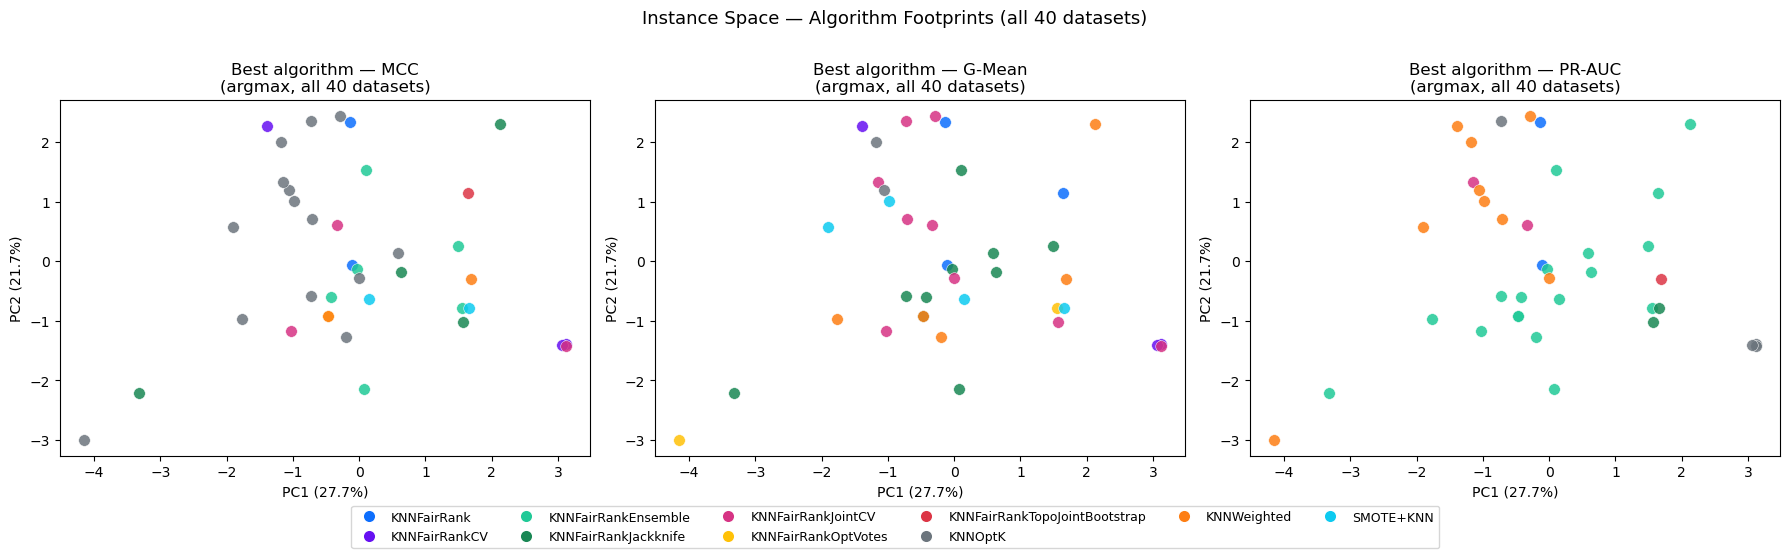

Winner counts per metric (argmax):
  MCC: {'KNNOptK': np.int64(14), 'KNNFairRankEnsemble': np.int64(6), 'KNNFairRankJackknife': np.int64(4), 'KNNFairRankCV': np.int64(3), 'KNNFairRankJointCV': np.int64(3), 'KNNFairRank': np.int64(2), 'KNNWeighted': np.int64(2), 'SMOTE+KNN': np.int64(2), 'KNNFairRankOptVotes': np.int64(1), 'KNNFairRankTopoJointBootstrap': np.int64(1)}
  G-Mean: {'KNNFairRankJackknife': np.int64(10), 'KNNFairRankJointCV': np.int64(9), 'KNNWeighted': np.int64(5), 'SMOTE+KNN': np.int64(4), 'KNNFairRank': np.int64(3), 'KNNFairRankCV': np.int64(3), 'KNNOptK': np.int64(2), 'KNNFairRankOptVotes': np.int64(2)}
  PR-AUC: {'KNNFairRankEnsemble': np.int64(18), 'KNNWeighted': np.int64(9), 'KNNOptK': np.int64(4), 'KNNFairRankJackknife': np.int64(2), 'KNNFairRank': np.int64(2), 'KNNFairRankJointCV': np.int64(2), 'KNNFairRankTopoJointBootstrap': np.int64(1)}


In [5]:
_ISA_METRICS = [("mcc","MCC"), ("g_mean","G-Mean"), ("pr_auc","PR-AUC")]

ALGOS_META = sorted(agg_all["algorithm"].unique())
PALETTE_META = {
    "KNNBase":                       "#adb5bd",
    "KNNOptK":                       "#6c757d",
    "KNNWeighted":                   "#fd7e14",
    "SMOTE+KNN":                     "#0dcaf0",
    "KNNFairRank":                   "#0d6efd",
    "KNNFairRankCV":                 "#6610f2",
    "KNNFairRankJointCV":            "#d63384",
    "KNNFairRankJackknife":          "#198754",
    "KNNFairRankEnsemble":           "#20c997",
    "KNNFairRankOptVotes":           "#ffc107",
    "KNNFairRankTopoJointBootstrap": "#dc3545",
}

# argmax winner — every dataset gets a colour, no ties
_win_df = isa_meta[["dataset","PC1","PC2"]].copy()
for _m, _ in _ISA_METRICS:
    _pivot = agg_all.pivot(index="dataset", columns="algorithm", values=_m)
    _win_df[f"{_m}_winner"] = _pivot.idxmax(axis=1).reindex(_win_df["dataset"]).values

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (_m, _label) in zip(axes, _ISA_METRICS):
    for algo in ALGOS_META:
        mask = _win_df[f"{_m}_winner"] == algo
        if not mask.any(): continue
        sub = _win_df[mask]
        ax.scatter(sub["PC1"], sub["PC2"], color=PALETTE_META.get(algo,"#999"),
                   s=70, alpha=0.85, edgecolors="white", linewidths=0.4, label=algo, zorder=3)
    ax.set_xlabel(f"PC1 ({_isa_var[0]:.1%})")
    ax.set_ylabel(f"PC2 ({_isa_var[1]:.1%})")
    ax.set_title(f"Best algorithm — {_label}\n(argmax, all 40 datasets)")

_foot_algos = [a for a in ALGOS_META if any((_win_df[f"{m}_winner"]==a).any() for m,_ in _ISA_METRICS)]
_foot_handles = [
    plt.Line2D([0],[0], marker="o", color="w", markerfacecolor=PALETTE_META.get(a,"#999"),
               markersize=9, label=a) for a in _foot_algos
]
fig.legend(handles=_foot_handles, loc="lower center", ncol=6,
           bbox_to_anchor=(0.5,-0.08), fontsize=9, frameon=True)
plt.suptitle("Instance Space — Algorithm Footprints (all 40 datasets)", fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig("results/figures/meta_isa_footprints.png", bbox_inches="tight")
plt.show()

print("Winner counts per metric (argmax):")
for _m, _label in _ISA_METRICS:
    counts = _win_df[f"{_m}_winner"].value_counts()
    print(f"  {_label}: {dict(counts)}")

## 5 · LODO-CV — 10-way algorithm selection

In [6]:
METRICS = [("g_mean", "G-Mean"), ("mcc", "MCC"), ("pr_auc", "PR-AUC")]

_all_ds = list(isa_meta["dataset"].unique())
_lodo_10way_all = {}  # metric -> (labels_dict, baseline, {learner: [rows]})

for _metric, _metric_label in METRICS:
    _labels = {
        ds: agg_all[agg_all["dataset"] == ds].set_index("algorithm")[_metric].idxmax()
        for ds in _all_ds
    }
    _winner_counts = pd.Series(list(_labels.values())).value_counts()
    _baseline = _winner_counts.iloc[0] / len(_all_ds)

    print(f"\n── {_metric_label} — baseline: {_baseline:.1%} ({_winner_counts.index[0]}) ──")
    print(_winner_counts.to_string())

    _lodo_results = {name: [] for name in META_LEARNERS}
    for _left_out in _all_ds:
        _train_names = [d for d in _all_ds if d != _left_out]
        _Xtr = isa_meta[isa_meta["dataset"].isin(_train_names)][_META_FEAT_COLS].values
        _Xte = isa_meta[isa_meta["dataset"] == _left_out][_META_FEAT_COLS].values
        _ytr = np.array([_labels[d] for d in _train_names])
        _yte = _labels[_left_out]
        for name, clf in META_LEARNERS.items():
            _clf = copy.deepcopy(clf)
            _clf.fit(_Xtr, _ytr)
            _pred = _clf.predict(_Xte)[0]
            _lodo_results[name].append({
                "dataset": _left_out, "true_winner": _yte,
                "pred_winner": _pred, "correct": _yte == _pred,
            })

    _lodo_10way_all[_metric] = (_labels, _baseline, _lodo_results)

    print(f"\n  {'Meta-learner':<20}  {'LODO Acc':>9}  {'vs Baseline':>12}")
    print("  " + "-" * 44)
    for name, rows in _lodo_results.items():
        df = pd.DataFrame(rows)
        acc = df["correct"].mean()
        print(f"  {name:<20}  {acc:>8.1%}  {acc - _baseline:>+11.1%}")

# backward-compat alias used by save cell
_lodo_10way = _lodo_10way_all["g_mean"][2]
_lodo_10way_dfs = {name: pd.DataFrame(rows) for name, rows in _lodo_10way.items()}
_baseline_10way = _lodo_10way_all["g_mean"][1]
_lodo_df = _lodo_10way_dfs[list(META_LEARNERS.keys())[0]]


── G-Mean — baseline: 26.3% (KNNFairRankJackknife) ──
KNNFairRankJackknife    10
KNNFairRankJointCV       9
KNNWeighted              5
SMOTE+KNN                4
KNNFairRank              3
KNNFairRankCV            3
KNNOptK                  2
KNNFairRankOptVotes      2

  Meta-learner           LODO Acc   vs Baseline
  --------------------------------------------
  KNN-5                    18.4%        -7.9%
  LogisticReg              23.7%        -2.6%
  RandomForest             15.8%       -10.5%
  GradientBoosting         15.8%       -10.5%
  SVM                      21.1%        -5.3%
  FairRankMC               15.8%       -10.5%
  FairRankMC-JKK           18.4%        -7.9%
  FairRankMC-LOO           15.8%       -10.5%

── MCC — baseline: 36.8% (KNNOptK) ──
KNNOptK                          14
KNNFairRankEnsemble               6
KNNFairRankJackknife              4
KNNFairRankCV                     3
KNNFairRankJointCV                3
KNNFairRank                       2
KNNWeighte

## 5.5 · FairRank Multiclass — 10-way comparison

Direct comparison of the FairRank multiclass variants against the best sklearn meta-learner on the 10-way task. 
The FairRank multiclass approach treats algorithm selection as a K-class imbalance problem: 
each algorithm class j has N_j training datasets where it won. 
The fair rank k_j = max(1, N_j / N_ref) uses the **median** class size as reference (N_ref = median_j N_j), 
so no single rare algorithm monopolises rank 1 and the correction for larger classes is proportional rather than extreme. 
The LOO variant re-runs the vote K times, each time excluding one algorithm class and recomputing the median from the remaining K-1 classes.

In [7]:
_FR_NAMES = ["FairRankMC", "FairRankMC-JKK", "FairRankMC-LOO"]

print("FairRank Multiclass — 10-way LODO results")
print()
for _metric, _metric_label in METRICS:
    _labels, _base_10, _results_10 = _lodo_10way_all[_metric]
    _winner_counts = pd.Series(list(_labels.values())).value_counts()
    print(f"── {_metric_label}  (baseline: {_base_10:.1%} — {_winner_counts.index[0]}) ──")
    print(f"  {chr(39)}Meta-learner{chr(39):<22}  {chr(39)}LODO Acc{chr(39):>9}  {chr(39)}vs Baseline{chr(39):>12}")
    print("  " + "-" * 47)
    _sk_accs = {name: pd.DataFrame(rows)["correct"].mean()
                for name, rows in _results_10.items() if name not in _FR_NAMES}
    _best_sk = max(_sk_accs, key=_sk_accs.get)
    _best_sk_acc = _sk_accs[_best_sk]
    _best_sk_label = _best_sk + " (best sklearn)"
    print(f"  {_best_sk_label:<22}  {_best_sk_acc:>8.1%}  {_best_sk_acc - _base_10:>+11.1%}")
    for name in _FR_NAMES:
        if name in _results_10:
            acc = pd.DataFrame(_results_10[name])["correct"].mean()
            print(f"  {name:<22}  {acc:>8.1%}  {acc - _base_10:>+11.1%}")
    print()


FairRank Multiclass — 10-way LODO results

── G-Mean  (baseline: 26.3% — KNNFairRankJackknife) ──
  'Meta-learner'                       'LODO Acc        '  'vs Baseline           '
  -----------------------------------------------
  LogisticReg (best sklearn)     23.7%        -2.6%
  FairRankMC                 15.8%       -10.5%
  FairRankMC-JKK             18.4%        -7.9%
  FairRankMC-LOO             15.8%       -10.5%

── MCC  (baseline: 36.8% — KNNOptK) ──
  'Meta-learner'                       'LODO Acc        '  'vs Baseline           '
  -----------------------------------------------
  RandomForest (best sklearn)     39.5%        +2.6%
  FairRankMC                  5.3%       -31.6%
  FairRankMC-JKK              5.3%       -31.6%
  FairRankMC-LOO             10.5%       -26.3%

── PR-AUC  (baseline: 47.4% — KNNFairRankEnsemble) ──
  'Meta-learner'                       'LODO Acc        '  'vs Baseline           '
  -----------------------------------------------
  SVM (best 

## 6 · Binary LODO-CV

In [8]:
_lodo_bin_all = {}  # metric -> (algo_a, algo_b, majority, baseline, {learner: [rows]})

for _metric, _metric_label in METRICS:
    # auto-detect top-2 algorithms by mean performance across all datasets
    _overall = agg_all.groupby("algorithm")[_metric].mean().sort_values(ascending=False)
    _BIN_A_m = _overall.index[0]
    _BIN_B_m = _overall.index[1]

    _metric_pivot = agg_all.pivot(index="dataset", columns="algorithm", values=_metric)
    _bin_labels_m = (_metric_pivot[_BIN_A_m] > _metric_pivot[_BIN_B_m]).astype(int)
    _majority_m   = float(_bin_labels_m.mean())
    _baseline_m   = max(_majority_m, 1 - _majority_m)

    print(f"\n── {_metric_label}: {_BIN_A_m} vs {_BIN_B_m} ──")
    print(f"  Win rate: {_majority_m:.1%}  ({int(_bin_labels_m.sum())}/{len(_bin_labels_m)})  baseline: {_baseline_m:.1%}")

    _lodo_results = {name: [] for name in META_LEARNERS}
    for _left_out in _all_ds:
        _train_names = [d for d in _all_ds if d != _left_out]
        _Xtr = isa_meta[isa_meta["dataset"].isin(_train_names)][_META_FEAT_COLS].values
        _Xte = isa_meta[isa_meta["dataset"] == _left_out][_META_FEAT_COLS].values
        _ytr = _bin_labels_m.reindex(_train_names).values
        _yte = int(_bin_labels_m[_left_out])
        for name, clf in META_LEARNERS.items():
            _clf = copy.deepcopy(clf)
            _clf.fit(_Xtr, _ytr)
            _pred = int(_clf.predict(_Xte)[0])
            _lodo_results[name].append({
                "dataset": _left_out, "label": _yte, "pred": _pred, "correct": _yte == _pred,
            })

    _lodo_bin_all[_metric] = (_BIN_A_m, _BIN_B_m, _majority_m, _baseline_m, _lodo_results)

    print(f"  {'Meta-learner':<20}  {'LODO Acc':>9}  {'vs Baseline':>12}")
    print("  " + "-" * 44)
    for name, rows in _lodo_results.items():
        df = pd.DataFrame(rows)
        acc = df["correct"].mean()
        print(f"  {name:<20}  {acc:>8.1%}  {acc - _baseline_m:>+11.1%}")

# backward-compat vars for stress test (section 7, g_mean)
_BIN_A, _BIN_B, _majority, _baseline_bin, _lodo_bin = _lodo_bin_all["g_mean"]
_gmean_pivot = agg_all.pivot(index="dataset", columns="algorithm", values="g_mean")
_bin_labels  = (_gmean_pivot[_BIN_A] > _gmean_pivot[_BIN_B]).astype(int)
_lodo_bin_dfs = {name: pd.DataFrame(rows) for name, rows in _lodo_bin.items()}
_bin_df  = _lodo_bin_dfs[list(META_LEARNERS.keys())[0]]
_bin_acc = _bin_df["correct"].mean()


── G-Mean: KNNFairRankJointCV vs KNNFairRankOptVotes ──
  Win rate: 57.5%  (23/40)  baseline: 57.5%
  Meta-learner           LODO Acc   vs Baseline
  --------------------------------------------
  KNN-5                    55.3%        -2.2%
  LogisticReg              73.7%       +16.2%
  RandomForest             60.5%        +3.0%
  GradientBoosting         55.3%        -2.2%
  SVM                      71.1%       +13.6%
  FairRankMC               65.8%        +8.3%
  FairRankMC-JKK           65.8%        +8.3%
  FairRankMC-LOO           65.8%        +8.3%

── MCC: KNNFairRankEnsemble vs KNNFairRankJointCV ──
  Win rate: 45.0%  (18/40)  baseline: 55.0%
  Meta-learner           LODO Acc   vs Baseline
  --------------------------------------------
  KNN-5                    55.3%        +0.3%
  LogisticReg              63.2%        +8.2%
  RandomForest             60.5%        +5.5%
  GradientBoosting         73.7%       +18.7%
  SVM                      57.9%        +2.9%
  FairRankMC 

## 7 · Feature importances — what drives algorithm selection?

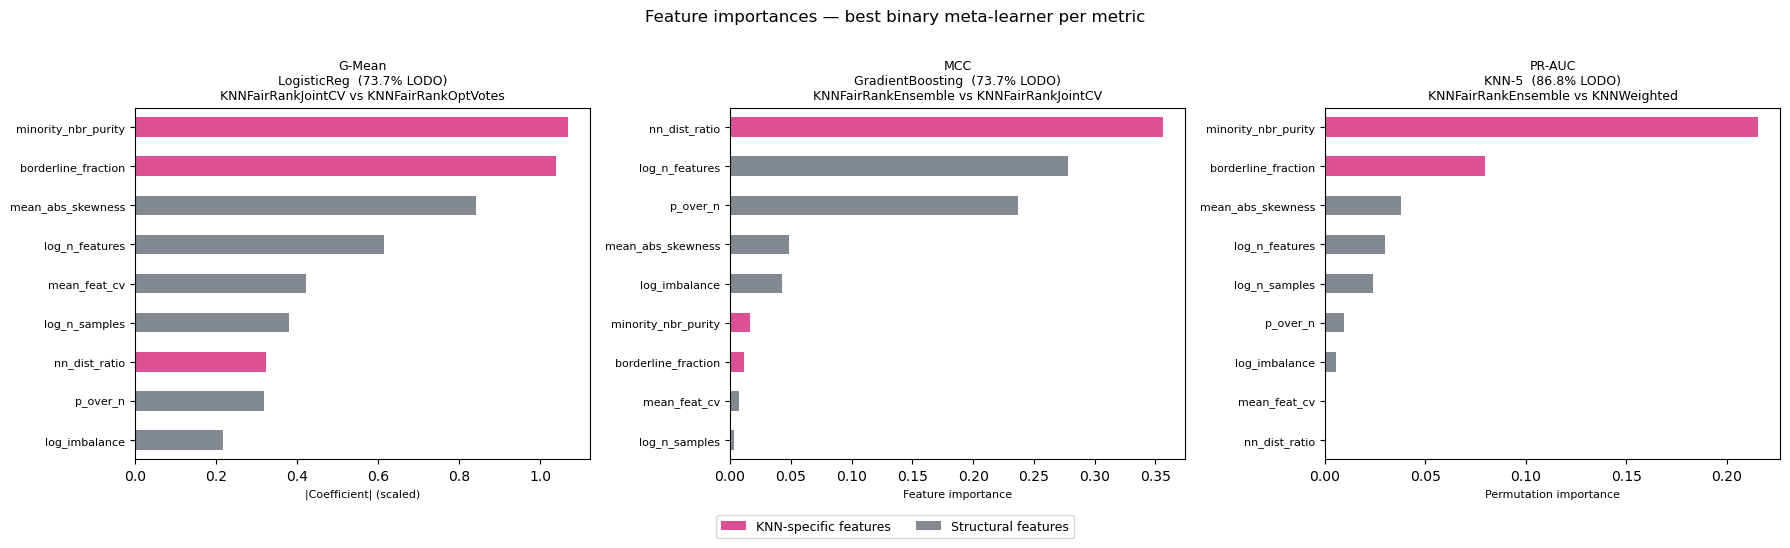

metric               g_mean     mcc  pr_auc
feature                                    
borderline_fraction  1.0393  0.0111  0.0798
log_imbalance        0.2167  0.0423  0.0053
log_n_features       0.6151  0.2783  0.0298
log_n_samples        0.3812  0.0031  0.0237
mean_abs_skewness    0.8407  0.0482  0.0377
mean_feat_cv         0.4216  0.0074  0.0000
minority_nbr_purity  1.0699  0.0162  0.2158
nn_dist_ratio        0.3233  0.3565  0.0000
p_over_n             0.3184  0.2369  0.0096


In [9]:
from sklearn.inspection import permutation_importance as _perm_imp

_X_full = isa_meta[_META_FEAT_COLS].values
_imp_records = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, (_metric, _metric_label) in zip(axes, METRICS):
    _a, _b, _maj, _base, _results = _lodo_bin_all[_metric]

    # best binary meta-learner for this metric
    _accs = {name: pd.DataFrame(rows)["correct"].mean() for name, rows in _results.items()}
    _best_name = max(_accs, key=_accs.get)
    _best_clf = copy.deepcopy(META_LEARNERS[_best_name])

    # train on all 40 datasets
    _metric_pivot = agg_all.pivot(index="dataset", columns="algorithm", values=_metric)
    _y_full = (
        _metric_pivot[_a] > _metric_pivot[_b]
    ).astype(int).reindex(isa_meta["dataset"].values).values
    _best_clf.fit(_X_full, _y_full)

    # extract importances depending on model type
    _est = _best_clf.steps[-1][1] if hasattr(_best_clf, "steps") else _best_clf
    if hasattr(_est, "feature_importances_"):
        importances = _est.feature_importances_
        imp_label = "Feature importance"
    elif hasattr(_est, "coef_"):
        coef = _est.coef_
        importances = np.abs(coef[0] if coef.ndim > 1 else coef)
        imp_label = "|Coefficient| (scaled)"
    else:
        r = _perm_imp(_best_clf, _X_full, _y_full, n_repeats=30, random_state=SEED)
        importances = r.importances_mean
        imp_label = "Permutation importance"

    _imp_series = pd.Series(importances, index=_META_FEAT_COLS).sort_values(ascending=True)
    _knn_feats = {"minority_nbr_purity", "nn_dist_ratio", "borderline_fraction"}
    colors = ["#d63384" if f in _knn_feats else "#6c757d" for f in _imp_series.index]

    _imp_series.plot.barh(ax=ax, color=colors, alpha=0.85)
    ax.set_title(f"{_metric_label}\n{_best_name}  ({_accs[_best_name]:.1%} LODO)\n{_a} vs {_b}",
                 fontsize=9)
    ax.set_xlabel(imp_label, fontsize=8)
    ax.tick_params(axis="y", labelsize=8)

    for feat, imp in _imp_series.items():
        _imp_records.append({"metric": _metric, "feature": feat,
                              "importance": imp, "meta_learner": _best_name})

_imp_df = pd.DataFrame(_imp_records)

from matplotlib.patches import Patch
_legend_handles = [
    Patch(facecolor="#d63384", alpha=0.85, label="KNN-specific features"),
    Patch(facecolor="#6c757d", alpha=0.85, label="Structural features"),
]
fig.legend(handles=_legend_handles, loc="lower center", ncol=2,
           bbox_to_anchor=(0.5, -0.06), fontsize=9)
plt.suptitle("Feature importances — best binary meta-learner per metric", fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("results/figures/meta_feature_importance.png", bbox_inches="tight")
plt.show()

print(_imp_df.pivot(index="feature", columns="metric", values="importance").round(4).to_string())

### 7.1 Formal trend tests on the IR axis

The Wilson CIs in §7 (n ≈ 10 per quartile) are *descriptive*. We complement them with
non-parametric rank-correlation tests (Kendall, Spearman) on two distinct comparisons:

1. **Main scientific question** — `KNNFairRankJointCV` vs `KNNOptK`. Does our proposed
   correction outperform the standard baseline more strongly as IR grows? The theoretical
   answer is yes (structural bias scales with $r$). A *flat* trend with high win rate would
   instead show **universal dominance** — even stronger than monotonic growth.

2. **Niche comparison** — the top-2 G-Mean pair used by the §6 binary LODO and §7 stress
   test (`KNNFairRankJointCV` vs `KNNFairRankOptVotes`, both of which crush KNNOptK). This
   tests *within the FairRank family* which variant pulls ahead in different IR regimes.


In [10]:
# ── Formal trend tests: does FairRank advantage grow with IR? ────────────
# Two questions tested:
#  1. KNNFairRankJointCV vs KNNOptK (main scientific: FairRank vs standard baseline)
#  2. The top-2-by-G-Mean pair used in §6 binary LODO (which §7 stress test uses)
from scipy.stats import kendalltau, spearmanr

_gp = agg_all.pivot(index='dataset', columns='algorithm', values='g_mean')

def _trend_report(label, algo_a, algo_b):
    """Compute and print binary + magnitude trend tests for (algo_a beats algo_b)."""
    if algo_a not in _gp.columns or algo_b not in _gp.columns:
        print(f"  {label}: skipped — algorithm missing from pivot.")
        return
    _wins = (_gp[algo_a] > _gp[algo_b]).reset_index()
    _wins.columns = ['dataset', 'wins']
    _merged = _wins.merge(isa_meta[['dataset','log_imbalance']], on='dataset')
    _gain = (_gp[algo_a] - _gp[algo_b]).reset_index()
    _gain.columns = ['dataset', 'delta']
    _gain_m = _gain.merge(isa_meta[['dataset','log_imbalance']], on='dataset')

    _tau_b, _p_tau_b = kendalltau(_merged['log_imbalance'], _merged['wins'])
    _tau_g, _p_tau_g = kendalltau(_gain_m['log_imbalance'], _gain_m['delta'])
    _rate = _merged['wins'].mean()
    _mean_d = _gain_m['delta'].mean()
    _drange = (_gain_m['delta'].min(), _gain_m['delta'].max())

    print(f"\n── {label}: {algo_a} vs {algo_b} ──")
    print(f"  Win rate:          {_rate:.0%}  ({int(_merged['wins'].sum())}/{len(_merged)})")
    print(f"  Mean Δ G-Mean:     {_mean_d:+.4f}  [{_drange[0]:+.4f}, {_drange[1]:+.4f}]")
    print(f"  Binary Kendall τ:  {_tau_b:+.3f}   p = {_p_tau_b:.4f}")
    print(f"  Magnitude Kendall τ: {_tau_g:+.3f}   p = {_p_tau_g:.4f}")
    if abs(_tau_b) < 0.15 and _p_tau_b > 0.05 and _rate > 0.7:
        print(f"  → Universal dominance (flat trend, high win rate).")
    elif _tau_b > 0 and _p_tau_b < 0.05:
        print(f"  → Significant positive trend (advantage grows with IR).")
    elif _tau_b < 0 and _p_tau_b < 0.05:
        print(f"  → Significant negative trend (advantage shrinks with IR).")
    else:
        print(f"  → No monotone trend at α=0.05.")

# ── 1. Main scientific question ──────────────────────────────────────────
_trend_report('Main (FairRank vs standard baseline)',
              'KNNFairRankJointCV', 'KNNOptK')

# ── 2. Same pair used in §7 stress test (top-2 by G-Mean) ────────────────
_trend_report(f'Top-2 by G-Mean (same as §7 stress test)', _BIN_A, _BIN_B)



── Main (FairRank vs standard baseline): KNNFairRankJointCV vs KNNOptK ──
  Win rate:          84%  (32/38)
  Mean Δ G-Mean:     +0.1460  [-0.0518, +0.6865]
  Binary Kendall τ:  +0.146   p = 0.2878
  Magnitude Kendall τ: +0.050   p = 0.6591
  → Universal dominance (flat trend, high win rate).

── Top-2 by G-Mean (same as §7 stress test): KNNFairRankJointCV vs KNNFairRankOptVotes ──
  Win rate:          55%  (21/38)
  Mean Δ G-Mean:     +0.0018  [-0.0608, +0.0524]
  Binary Kendall τ:  -0.018   p = 0.8947
  Magnitude Kendall τ: +0.106   p = 0.3618
  → No monotone trend at α=0.05.


## 8 · Save results

In [11]:
os.makedirs("results/tables", exist_ok=True)

_summary_rows = []

for _metric, _metric_label in METRICS:
    # 10-way
    _labels, _base_10, _results_10 = _lodo_10way_all[_metric]
    _rows_10 = []
    for name, rows in _results_10.items():
        df = pd.DataFrame(rows)
        acc = df["correct"].mean()
        _rows_10.append({"meta_learner": name, "lodo_acc": acc, "baseline": _base_10,
                         "vs_baseline": acc - _base_10, "n_datasets": len(df)})
    _compare_10 = pd.DataFrame(_rows_10).sort_values("lodo_acc", ascending=False)
    _compare_10.to_csv(f"results/tables/meta_lodo_10way_{_metric}.csv", index=False)

    # binary
    _a, _b, _maj, _base_bin, _results_bin = _lodo_bin_all[_metric]
    _rows_bin = []
    for name, rows in _results_bin.items():
        df = pd.DataFrame(rows)
        acc = df["correct"].mean()
        _rows_bin.append({"meta_learner": name, "lodo_acc": acc, "baseline": _base_bin,
                          "vs_baseline": acc - _base_bin, "n_datasets": len(df)})
    _compare_bin = pd.DataFrame(_rows_bin).sort_values("lodo_acc", ascending=False)
    _compare_bin.to_csv(f"results/tables/meta_lodo_binary_{_metric}.csv", index=False)

    _best_10  = _compare_10.iloc[0]
    _best_bin = _compare_bin.iloc[0]
    _summary_rows += [
        {"Metric": f"10-way LODO ({_metric_label}, best: {_best_10['meta_learner']})",
         "Value": f"{_best_10['lodo_acc']:.1%}", "Baseline": f"{_base_10:.1%} (majority class)", "n": 40},
        {"Metric": f"Binary LODO ({_metric_label}: {_a} vs {_b}, best: {_best_bin['meta_learner']})",
         "Value": f"{_best_bin['lodo_acc']:.1%}", "Baseline": f"{_base_bin:.1%} (majority class)", "n": 40},
    ]

_imp_df.to_csv("results/tables/meta_feature_importance.csv", index=False)
pd.DataFrame(_summary_rows).to_csv("results/tables/meta_model_results.csv", index=False)

print("Saved:")
for _metric, _ in METRICS:
    print(f"  results/tables/meta_lodo_10way_{_metric}.csv")
    print(f"  results/tables/meta_lodo_binary_{_metric}.csv")
print("  results/tables/meta_feature_importance.csv")
print("  results/tables/meta_model_results.csv")
print("\n── Summary ──")
display(pd.DataFrame(_summary_rows))

Saved:
  results/tables/meta_lodo_10way_g_mean.csv
  results/tables/meta_lodo_binary_g_mean.csv
  results/tables/meta_lodo_10way_mcc.csv
  results/tables/meta_lodo_binary_mcc.csv
  results/tables/meta_lodo_10way_pr_auc.csv
  results/tables/meta_lodo_binary_pr_auc.csv
  results/tables/meta_feature_importance.csv
  results/tables/meta_model_results.csv

── Summary ──


,Metric,Value,Baseline,n
0,"10-way LODO (G-Mean, best: LogisticReg)",23.7%,26.3% (majority class),40
1,Binary LODO (G-Mean: KNNFairRankJointCV vs KNN...,73.7%,57.5% (majority class),40
2,"10-way LODO (MCC, best: RandomForest)",39.5%,36.8% (majority class),40
3,Binary LODO (MCC: KNNFairRankEnsemble vs KNNFa...,73.7%,55.0% (majority class),40
4,"10-way LODO (PR-AUC, best: SVM)",68.4%,47.4% (majority class),40
5,Binary LODO (PR-AUC: KNNFairRankEnsemble vs KN...,86.8%,52.5% (majority class),40
